In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate correlated Gaussians with correlation rho
def generate_gaussian_samples(n_samples, rho):
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]
    data = np.random.multivariate_normal(mean, cov, size=n_samples)
    x = data[:, 0:1]
    y = data[:, 1:2]
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# 2. Define the MINE network
class MINE(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(MINE, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x, y):
        xy = torch.cat((x, y), dim=1)
        return self.net(xy)

# 3. MINE loss function
def mine_loss(joint, marginal):
    joint_term = torch.mean(joint)
    marginal_term = torch.log(torch.mean(torch.exp(marginal)))
    return -(joint_term - marginal_term)

# 4. Training function
def train_mine(mine, x, y, batch_size=128, epochs=500, lr=1e-3):
    dataset = TensorDataset(x, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(mine.parameters(), lr=lr)

    mi_estimates = []

    for epoch in range(epochs):
        epoch_loss = 0.0
        for xb, yb in loader:
            # Positive (joint) and negative (marginal) pairs
            joint = mine(xb, yb)
            y_shuffled = yb[torch.randperm(yb.size(0))]
            marginal = mine(xb, y_shuffled)

            loss = mine_loss(joint, marginal)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += -loss.item()

        avg_mi = epoch_loss / len(loader)
        mi_estimates.append(avg_mi)
        if epoch % 50 == 0:
            print(f"Epoch {epoch} | MI Estimate: {avg_mi:.4f}")

    return mi_estimates


True Mutual Information: 0.5108 nats
Epoch 0 | MI Estimate: 0.4830
Epoch 50 | MI Estimate: 0.5012
Epoch 100 | MI Estimate: 0.4993
Epoch 150 | MI Estimate: 0.5018
Epoch 200 | MI Estimate: 0.5032
Epoch 250 | MI Estimate: 0.5070
Epoch 300 | MI Estimate: 0.5087
Epoch 350 | MI Estimate: 0.5136
Epoch 400 | MI Estimate: 0.5089
Epoch 450 | MI Estimate: 0.4972


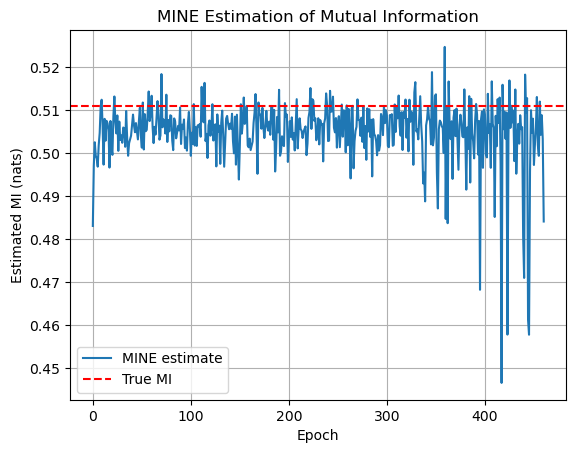

In [4]:
# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Ground truth MI for rho
rho = 0.8
true_mi = -0.5 * np.log(1 - rho**2)
print(f"True Mutual Information: {true_mi:.4f} nats")

# Generate data
x, y = generate_gaussian_samples(n_samples=100000, rho=rho)

# Initialize and train MINE
mine = MINE(input_size=2, hidden_size=128)
mi_estimates = train_mine(mine, x, y)

# Plot
plt.plot(mi_estimates, label="MINE estimate")
plt.axhline(true_mi, color="red", linestyle="--", label="True MI")
plt.xlabel("Epoch")
plt.ylabel("Estimated MI (nats)")
plt.legend()
plt.title("MINE Estimation of Mutual Information")
plt.grid(True)
plt.show()
